# Week 4 - EDA

Additional References:
- [Google Colab](https://colab.research.google.com/?utm_source=scs-index)
- [Pandas Documentation](https://pandas.pydata.org/docs/index.html)
- [Python for Beginners](https://www.python.org/about/gettingstarted/)

## Business Understanding

-  Bank Churn: Customers that defaulted from the credit card company.
- Goal: Understand customers based on bank churn data.

## Data Understanding

In [7]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### Preliminaries

Step 1. Set up project directory.

```
lastname_project
|---data                          # Directory for source data (*.csv)
    |---churn_test_20240126.csv   # Source data
|---notebook                      # Directory for Colab Notebook (*.ipynb)
    |---lastname_project.ipynb    # Colab Notebook
```

Step 2. Move source data into your Google Drive.

Step 3. Mount your Google Drive.

### Packages

In [8]:
#### Import packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

### Data

In [9]:
#### Read data
pdf = pd.read_csv('/content/drive/MyDrive/Work/PORTFOLIO/DATA ANALYTICS/Machine Learning Endeavor (Customer Churn)/data/churn_test_20240126.csv')

In [10]:
#### Basic information
pdf.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2026 entries, 0 to 2025
Data columns (total 7 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   CLIENTNUM               2026 non-null   int64  
 1   Attrition_Flag          2026 non-null   int64  
 2   Customer_Age            2026 non-null   int64  
 3   Dependent_count         2026 non-null   int64  
 4   Months_Inactive_12_mon  2026 non-null   int64  
 5   Credit_Limit            2026 non-null   float64
 6   Total_Trans_Amt         2026 non-null   int64  
dtypes: float64(1), int64(6)
memory usage: 110.9 KB


In [11]:
#### Shape
pdf.shape

(2026, 7)

In [12]:
#### Null
pdf.isnull().sum()

,0
CLIENTNUM,0
Attrition_Flag,0
Customer_Age,0
Dependent_count,0
Months_Inactive_12_mon,0
Credit_Limit,0
Total_Trans_Amt,0


In [13]:
### Duplicate
pdf.duplicated().sum()

np.int64(0)

In [14]:
#### First 5 rows
pdf.head()

,CLIENTNUM,Attrition_Flag,Customer_Age,Dependent_count,Months_Inactive_12_mon,Credit_Limit,Total_Trans_Amt
0,719455083,0,48,3,3,2991.0,3734
1,773503308,0,59,1,5,2192.0,4010
2,715452408,0,37,2,3,1734.0,4727
3,711264033,0,47,3,2,4786.0,4973
4,718943508,0,42,3,3,3714.0,1454


## EDA

### Numerical Descriptive Statistics

In [15]:
#### Get descriptive statistics
pdf[['Customer_Age', 'Dependent_count', 'Months_Inactive_12_mon', 'Credit_Limit', 'Total_Trans_Amt']].describe()

,Customer_Age,Dependent_count,Months_Inactive_12_mon,Credit_Limit,Total_Trans_Amt
count,2026.000000,2026.000000,2026.000000,2026.000000,2026.000000
mean,46.404245,2.391905,2.318361,8613.583021,4408.477295
std,7.995428,1.334967,0.996204,9100.417269,3379.585684
min,26.000000,0.000000,0.000000,1438.300000,530.000000
25%,41.000000,1.000000,2.000000,2571.250000,2147.250000
50%,46.000000,2.000000,2.000000,4563.500000,3908.000000
75%,52.000000,3.000000,3.000000,10707.500000,4750.750000
max,73.000000,5.000000,6.000000,34516.000000,16920.000000


### Attrition_Flag

In [16]:
#### Count Attrition_Flag by value
pdf['Attrition_Flag'].value_counts()

,count
Attrition_Flag,
0,1699
1,327


<Axes: xlabel='Attrition_Flag'>

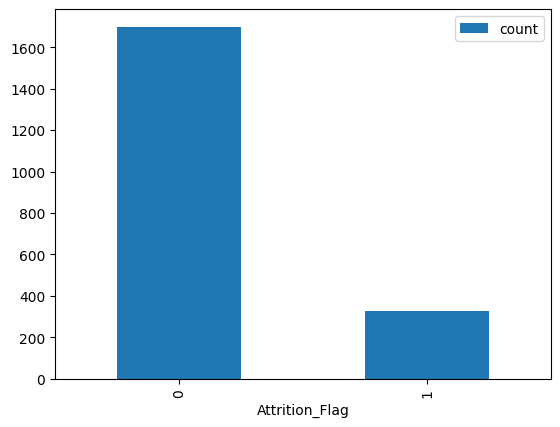

In [17]:
#### Plot Attrition_Flag bar graph
pdf['Attrition_Flag'].value_counts().plot(kind='bar', legend=True)

The plot represents the customer attrition in the company, it shows that 1699 customers have stayed, while 327 customers churned.

### Customer_Age vs Attrition_Flag

In [18]:
#### Get mean of Customer_Age vs Attrition_Flag
pdf.groupby('Attrition_Flag').mean()['Customer_Age']

,Customer_Age
Attrition_Flag,
0,46.579164
1,45.495413


<Axes: xlabel='Attrition_Flag'>

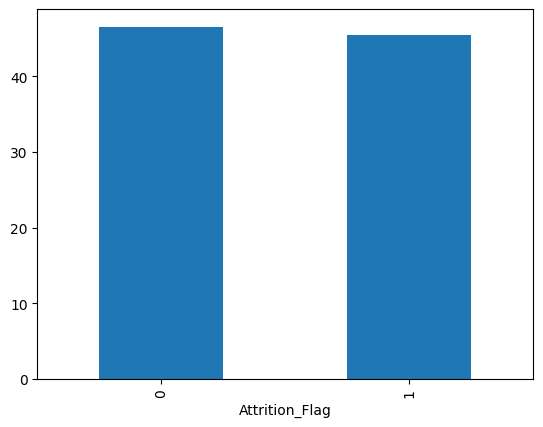

In [19]:
#### Plot mean of Customer_Age vs Attrition_Flag
pdf.groupby('Attrition_Flag').mean()['Customer_Age'].plot(kind='bar')

The plot shows the mean age of customers in relation to their attrition status. It shows that customers who have stayed have higher mean age of 46.6 years, while thos who churned has 45.5 average age. This suggests that younger customers are slightly more likely to leave the company.

,Customer_Age
Attrition_Flag,
0,"Axes(0.125,0.11;0.775x0.77)"
1,"Axes(0.125,0.11;0.775x0.77)"


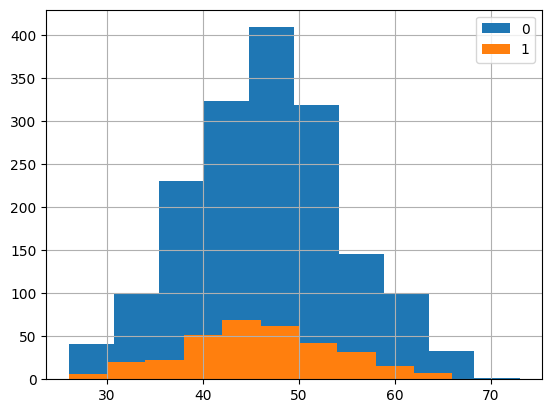

In [20]:
#### Plot histogram of Customer_Age vs Attrition_Flag
pdf.groupby('Attrition_Flag')['Customer_Age'].hist(legend=True)

The histogram shows the distribution of customer age in relation to their attrition status. The histogram shows that there is a significantly large difference between the customers who stayed and those who left regardless of which age bracket they belong.

### Dependent_count vs Attrition_Flag

In [21]:
#### Get mean Dependent_count vs Attrition_Flag
pdf.groupby('Attrition_Flag').mean()['Dependent_count']

,Dependent_count
Attrition_Flag,
0,2.384344
1,2.431193


<Axes: xlabel='Attrition_Flag'>

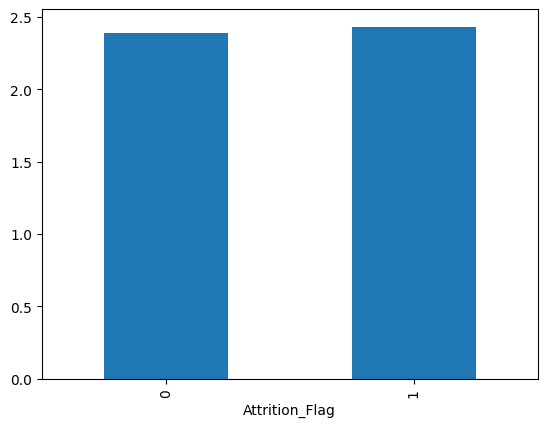

In [22]:
#### Plot mean Dependent_count vs Attrition_Flag
pdf.groupby('Attrition_Flag').mean()['Dependent_count'].plot(kind='bar')

The plot indicates that those who stayed have almost the same number of dependent count/supplementary cards. This can mean that the number of dependents or supplementary cards a customer has does not significantly influence their decision to stay or leave.

,Dependent_count
Attrition_Flag,
0,"Axes(0.125,0.11;0.775x0.77)"
1,"Axes(0.125,0.11;0.775x0.77)"


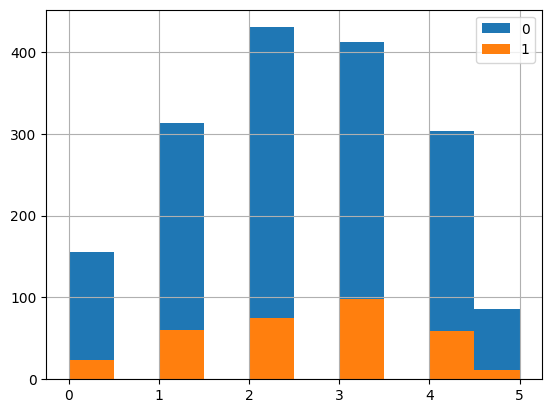

In [23]:
#### Plot histogram of Dependent_count vs Attrition_Flag
pdf.groupby('Attrition_Flag')['Dependent_count'].hist(legend=True)

The histogram shows the distribution of customers based on their  their dependent count or number of supplementary cards in relation to their attrition status. It show that customers with fewer supplementary cards have more tendency to churn, while those with higher dependent count have less tendency to churn.

### Months_Inactive_12_mon vs Attrition_Flag

In [24]:
#### Get mean Months_Inactive_12_mon vs Attrition_Flag
pdf.groupby('Attrition_Flag').mean()['Months_Inactive_12_mon']

,Months_Inactive_12_mon
Attrition_Flag,
0,2.258976
1,2.626911


<Axes: xlabel='Attrition_Flag'>

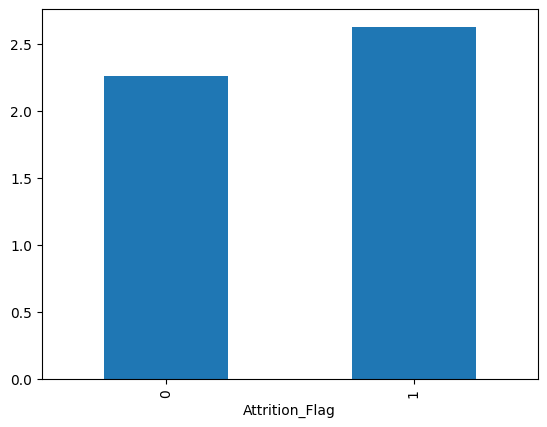

In [25]:
#### Plot mean Months_Inactive_12_mon vs Attrition_Flag
pdf.groupby('Attrition_Flag').mean()['Months_Inactive_12_mon'].plot(kind='bar')

The plot indicates that a longer or higher period of month inactivity slightly increases the likelihood of a customer churn.

### Credit_Limit vs Attrition_Flag

In [26]:
#### Get mean Credit_Limit vs Attrition_Flag
pdf.groupby('Attrition_Flag').mean()['Credit_Limit']

,Credit_Limit
Attrition_Flag,
0,8699.889935
1,8165.156575


<Axes: xlabel='Attrition_Flag'>

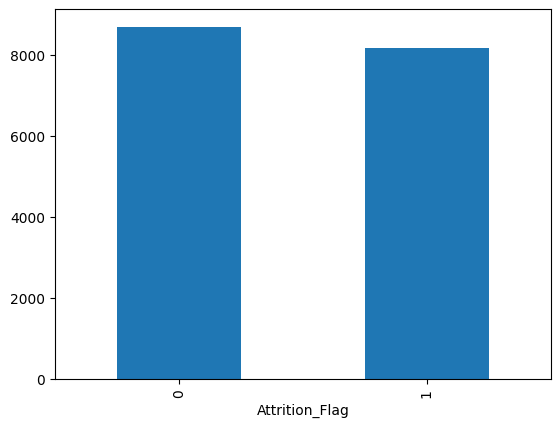

In [27]:
#### Plot mean Credit_Limit vs Attrition_Flag
pdf.groupby('Attrition_Flag').mean()['Credit_Limit'].plot(kind='bar')

The plot signifies that those with higher credit limit are slightly more likely to stay with the company.

### Total_Trans_Amt vs Attrition_Flag

In [28]:
#### Get mean Total_Trans_Amt vs Attrition_Flag
pdf.groupby('Attrition_Flag').mean()['Total_Trans_Amt']

,Total_Trans_Amt
Attrition_Flag,
0,4601.972925
1,3403.128440


<Axes: xlabel='Attrition_Flag'>

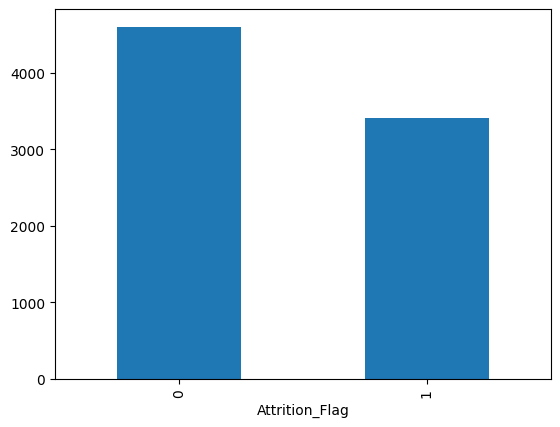

In [29]:
#### Plot mean Total_Trans_Amt vs Attrition_Flag
pdf.groupby('Attrition_Flag').mean()['Total_Trans_Amt'].plot(kind='bar')

The plot suggests that customers with a higher total transaction are more likely to stay with the company. With a higher mean difference we could say that total transaction amount is a strong indicator of customer attrition.